In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model15_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model15_0)
describe(model15_0)

MACs: 5.85 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model15_0.pt
Starting
Epoch 1/60: Train loss = 1.1370, Train accuracy = 0.5957, Test loss = 1.1067, Test accuracy = 0.6059
Epoch 2/60: Train loss = 1.0229, Train accuracy = 0.6456, Test loss = 1.0537, Test accuracy = 0.6383
Epoch 3/60: Train loss = 0.8849, Train accuracy = 0.6884, Test loss = 0.8627, Test accuracy = 0.6974
Epoch 4/60: Train loss = 0.7503, Train accuracy = 0.7370, Test loss = 0.7363, Test accuracy = 0.7420
Epoch 5/60: Train loss = 0.8134, Train accuracy = 0.7145, Test loss = 0.8267, Test accuracy = 0.7115
Epoch 6/60: Train loss = 0.7164, Train accuracy = 0.7481, Test loss = 0.7153, Test accuracy = 0.7532
Epoch 7/60: Train loss = 0.6721, Train accuracy = 0.7648, Test loss = 0.6864, Test accuracy = 0.7586
Epoch 8/60: Train loss = 0.6531, Train accuracy = 0.7737, Test loss = 0.6632, Test accuracy = 0.7748
Epoch 9/60: Train loss = 0.6743, Train accuracy = 0.7676, Test loss = 0.7191, Test accuracy = 0.7610
Epoch 10/60: Train loss = 0.618

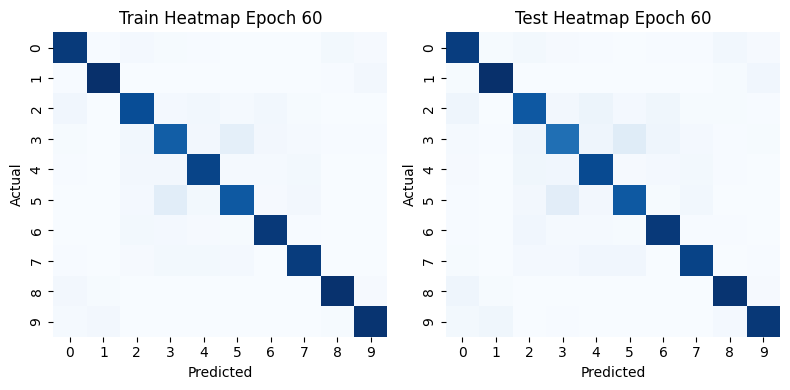

<Figure size 1200x600 with 0 Axes>

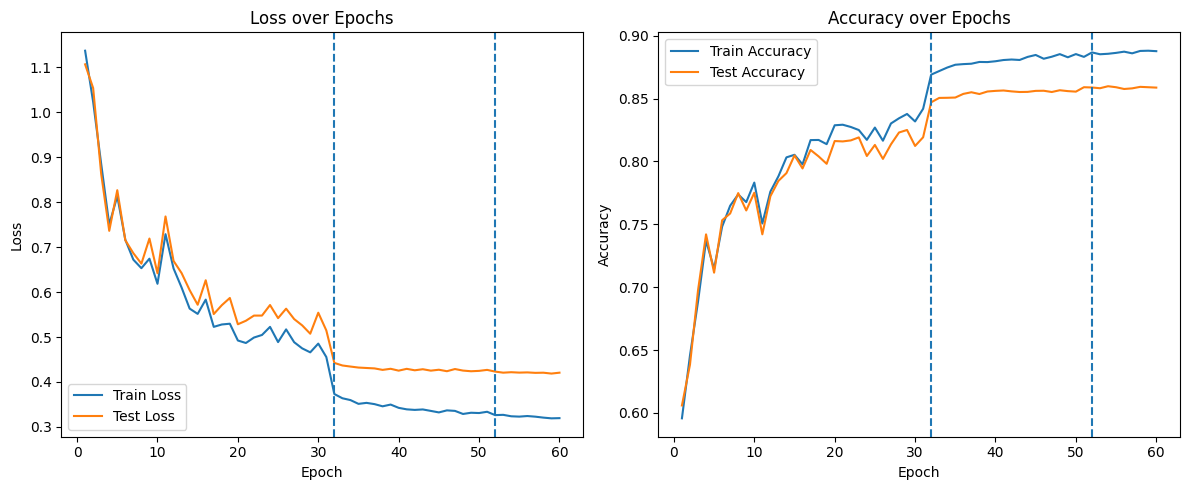

In [6]:
trainf32(model15_0,"model_weights/model15_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model15_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model15_1)
describe(model15_1)

MACs: 5.85 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model15_1.pt
Starting
Epoch 1/60: Train loss = 1.0703, Train accuracy = 0.6252, Test loss = 1.0452, Test accuracy = 0.6372
Epoch 2/60: Train loss = 0.8631, Train accuracy = 0.6957, Test loss = 0.8377, Test accuracy = 0.7053
Epoch 3/60: Train loss = 0.7795, Train accuracy = 0.7317, Test loss = 0.7891, Test accuracy = 0.7289
Epoch 4/60: Train loss = 0.7395, Train accuracy = 0.7405, Test loss = 0.7499, Test accuracy = 0.7424
Epoch 5/60: Train loss = 0.6603, Train accuracy = 0.7697, Test loss = 0.6824, Test accuracy = 0.7668
Epoch 6/60: Train loss = 0.6754, Train accuracy = 0.7648, Test loss = 0.6836, Test accuracy = 0.7660
Epoch 7/60: Train loss = 0.6299, Train accuracy = 0.7801, Test loss = 0.6385, Test accuracy = 0.7783
Epoch 8/60: Train loss = 0.6600, Train accuracy = 0.7707, Test loss = 0.6804, Test accuracy = 0.7701
Epoch 9/60: Train loss = 0.6224, Train accuracy = 0.7826, Test loss = 0.6358, Test accuracy = 0.7791
Epoch 10/60: Train loss = 0.669

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 31/60: Train loss = 0.4402, Train accuracy = 0.8481, Test loss = 0.4865, Test accuracy = 0.8340
Epoch 32/60: Train loss = 0.3549, Train accuracy = 0.8752, Test loss = 0.4239, Test accuracy = 0.8569
Epoch 33/60: Train loss = 0.3494, Train accuracy = 0.8787, Test loss = 0.4238, Test accuracy = 0.8572
Epoch 34/60: Train loss = 0.3399, Train accuracy = 0.8818, Test loss = 0.4159, Test accuracy = 0.8613
Epoch 35/60: Train loss = 0.3358, Train accuracy = 0.8822, Test loss = 0.4128, Test accuracy = 0.8631
Epoch 36/60: Train loss = 0.3337, Train accuracy = 0.8833, Test loss = 0.4119, Test accuracy = 0.8652
Epoch 37/60: Train loss = 0.3308, Train accuracy = 0.8841, Test loss = 0.4115, Test accuracy = 0.8639
Epoch 38/60: Train loss = 0.3297, Train accuracy = 0.8836, Test loss = 0.4136, Test accuracy = 0.8622
Epoch 39/60: Train loss = 0.3273, Train accuracy = 0.8864, Test loss = 0.4174, Test accuracy = 0.8640
Epoch 40/60: Train loss = 0.3251, Train accuracy = 0.8873, Test loss = 0.4117, Tes

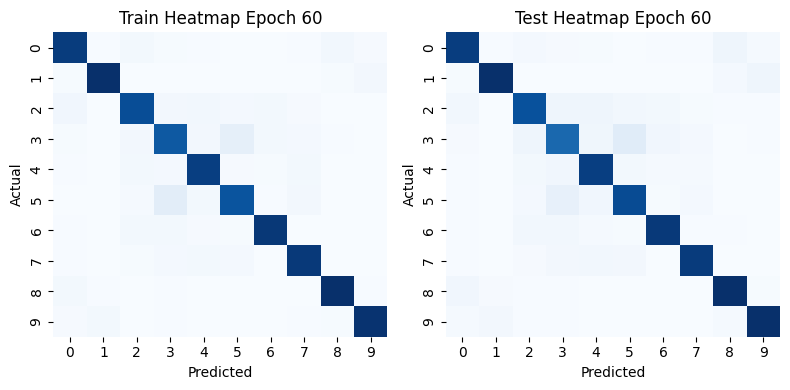

<Figure size 1200x600 with 0 Axes>

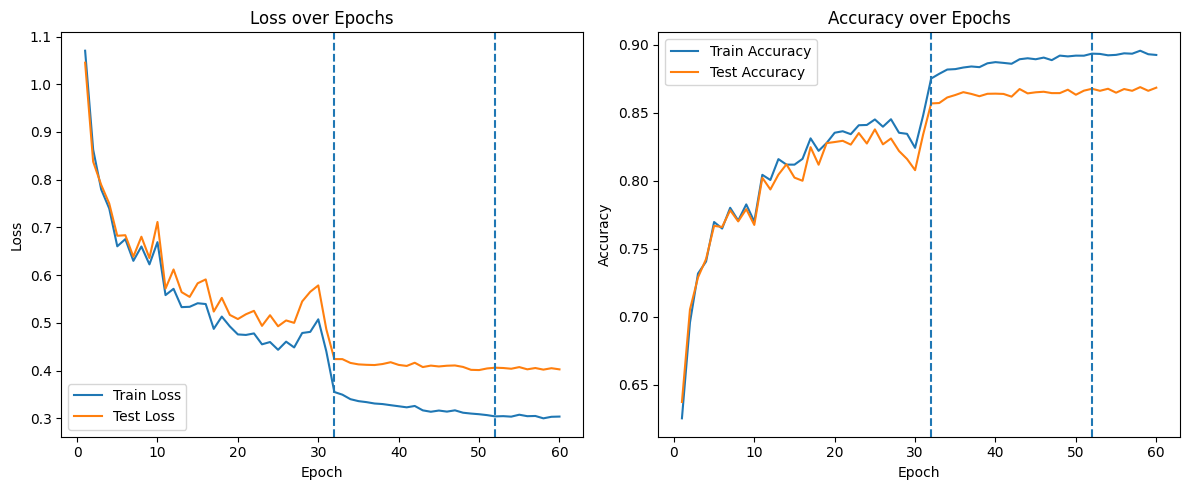

In [10]:
trainf32(model15_1,"model_weights/model15_1.pt",criterion,train_dataset,val_dataset, batch_size=64)